# Example of using Torch SRS methods

Import statements

In [3]:
import torch
from gen_srs_public.Data.basis_functions import BasisGeneratorConfig, BasisSetConfig
from gen_srs_public.Data.generate_time_series import generate_shocks, ShockGenerationConfig
from gen_srs_public.Utilities.isoSRS_torch import TorchSRS
from gen_srs_public.Utilities.frequency_sampler import get_sampler
from gen_srs_public.Plotting.plot import plot_shock_and_srs_examples

Generate some example shock time series first 

In [4]:
n_shocks = 1000    # N
ts_length = 9000  # L
sample_rate = 32768
device = "cuda" if torch.cuda.is_available() else "cpu"

generator_config = BasisGeneratorConfig(
    device=device,
    ts_length=ts_length,
    sample_rate=sample_rate,
)

basis_config = BasisSetConfig(
    generator=generator_config,
    names=("morlet_wavelet", "decayed_sine"),
)

shock_config = ShockGenerationConfig(
    num_shocks=n_shocks,
    normalize=False,
)

x = generate_shocks(generation_config=shock_config, basis_config=basis_config)

Generating time series: 100%|##########| 88.0/88.0 [00:00<00:00, 228batch/s]


Calculate the frequency range vector

In [5]:
# setup Frequencies
freq_sampler = get_sampler('logspace', f_low=10, f_high=4096)  # What time of frequency sampling logspace, uniform, etc..,
freqs = freq_sampler(1, 100)  # (100,)  Sample frequencies

Instantiate SRS object and run the batch method 

In [6]:
srs_fn = TorchSRS(device, sample_rate=sample_rate, pad_scale=3)  # this fn returns SRS given ts
y_srs = srs_fn.batch(x.shocks, freqs, batch_size=32, max=True, progress=True) # Batch Compute the SRS for the generated synthetic shocks and show progress bar

Calculating SRS: 100%|##########| 32.0/32.0 [00:00<00:00, 44.4batch/s]


Show Plot

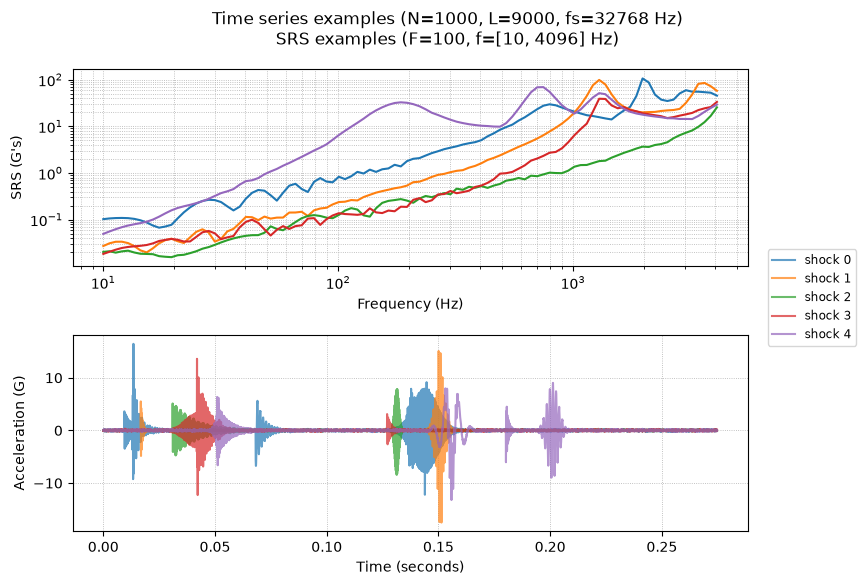

In [7]:
plot_shock_and_srs_examples(x.shocks, y_srs, freqs, sample_rate, k=5)